In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Charger les données ACP
X_pca = pd.read_csv("D:/imen-chabchoub/FAC/BDIA2-2/data-mining/datamining1/data/processed/X_pca_clusters.csv")

X_pca_2 = X_pca[["PC1", "PC2"]].values
y = X_pca["price_range"].values

In [3]:

# K‑means sur les 2 premiers axes de l’ACP
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_pca_2)

# Créer un DataFrame avec PC1, PC2, clusters et price_range
data_acp = X_pca[["PC1", "PC2"]].copy()   # uniquement les colonnes PC1, PC2
data_acp["cluster"] = clusters
data_acp["price_range"] = y

print("Répartition des clusters :")
print(data_acp["cluster"].value_counts())

Répartition des clusters :
cluster
3    640
0    523
1    500
2    337
Name: count, dtype: int64


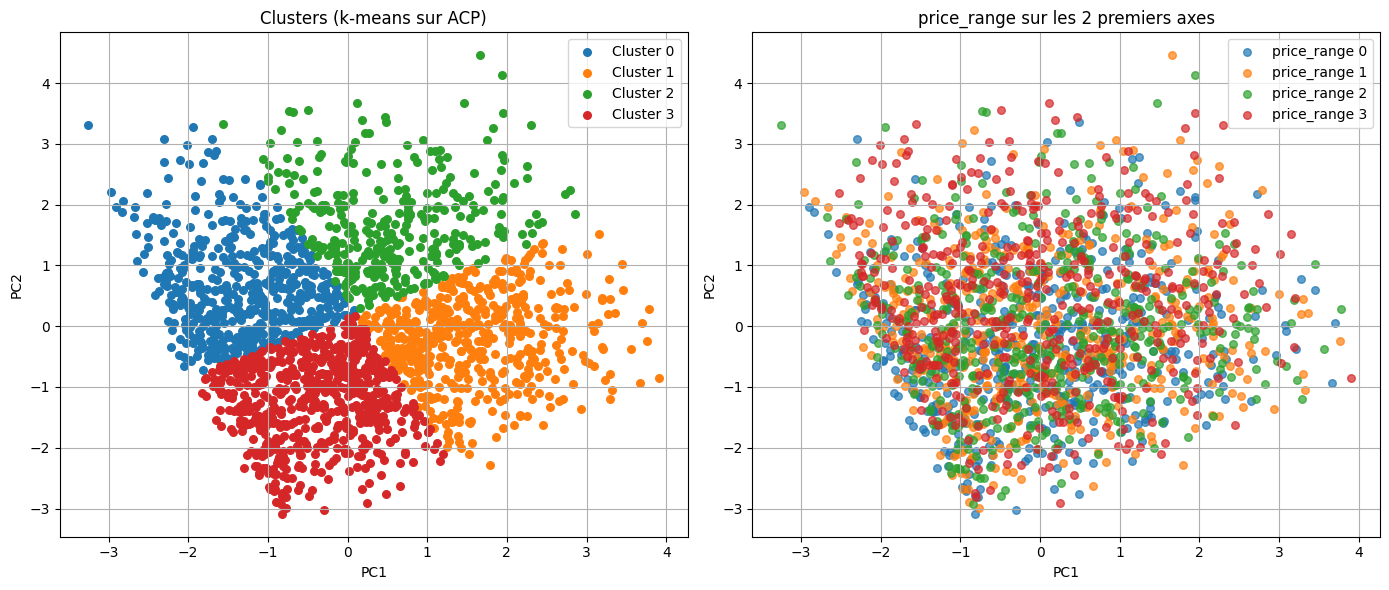

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Cluster vs axe 1-2
plt.subplot(1, 2, 1)
for i in range(k):
    mask = (clusters == i)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"Cluster {i}", s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters (k‑means sur ACP)")
plt.legend()
plt.grid(True)

# Clusters colorés par price_range
plt.subplot(1, 2, 2)
for c in np.sort(np.unique(y)):   # ici np.unique au lieu de y.unique()
    mask = (y == c)
    plt.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=f"price_range {c}", s=30, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("price_range sur les 2 premiers axes")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()